In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s4e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e4/train.csv
/kaggle/input/competitions/playground-series-s4e4/test.csv


In [2]:
#  Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/test.csv")
sub_data = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/sample_submission.csv")

print(train_data.columns.tolist())

['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings']


In [4]:
train_data.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


<Axes: >

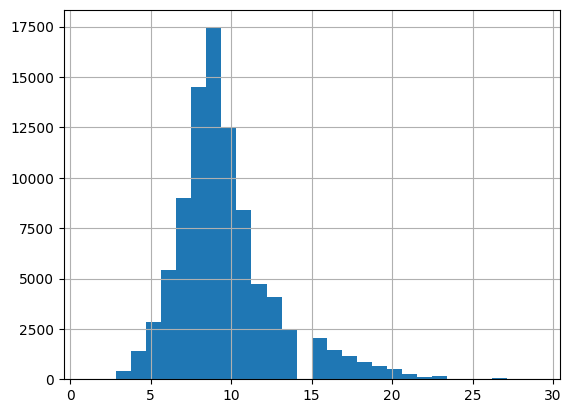

In [5]:
train_data['Rings'].hist(bins=30)

Since the data is right skewed we need to make it more symmentric to make the data balanced otherwise the model will be better at predicting the lower ring values (5-13). We do this by logging the ring value and we do `log1p` to avoid `log(0)` case since its `undefined`

<Axes: >

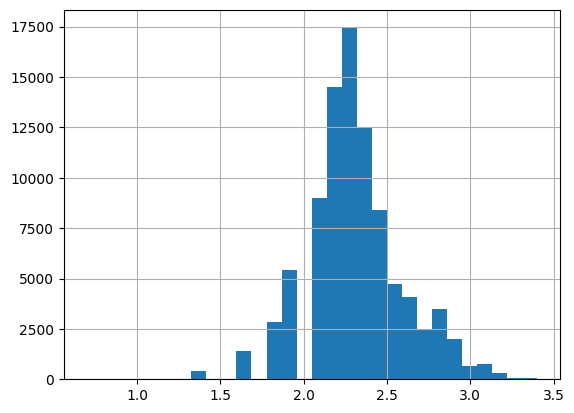

In [6]:
np.log1p(train_data['Rings']).hist(bins=30)

In [7]:
train_data.corr(numeric_only=True)

,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
id,1.000000,0.004724,0.004290,0.005916,0.005228,0.004203,0.004878,0.005887,0.000938
Length,0.004724,1.000000,0.989732,0.916094,0.931449,0.909609,0.913134,0.911073,0.623786
Diameter,0.004290,0.989732,1.000000,0.919618,0.933848,0.908466,0.914668,0.917871,0.636832
Height,0.005916,0.916094,0.919618,1.000000,0.902344,0.861769,0.886132,0.904019,0.665772
Whole weight,0.005228,0.931449,0.933848,0.902344,1.000000,0.971249,0.974319,0.964201,0.617274
Whole weight.1,0.004203,0.909609,0.908466,0.861769,0.971249,1.000000,0.949227,0.911800,0.515067
Whole weight.2,0.004878,0.913134,0.914668,0.886132,0.974319,0.949227,1.000000,0.937069,0.588954
Shell weight,0.005887,0.911073,0.917871,0.904019,0.964201,0.911800,0.937069,1.000000,0.694766
Rings,0.000938,0.623786,0.636832,0.665772,0.617274,0.515067,0.588954,0.694766,1.000000


In [8]:
train_data.corr(numeric_only=True)["Rings"]

id                0.000938
Length            0.623786
Diameter          0.636832
Height            0.665772
Whole weight      0.617274
Whole weight.1    0.515067
Whole weight.2    0.588954
Shell weight      0.694766
Rings             1.000000
Name: Rings, dtype: float64

In [9]:
train_data.corr(numeric_only=True)["Rings"][:-1].sort_values(ascending=False)

Shell weight      0.694766
Height            0.665772
Diameter          0.636832
Length            0.623786
Whole weight      0.617274
Whole weight.2    0.588954
Whole weight.1    0.515067
id                0.000938
Name: Rings, dtype: float64

In [10]:
(train_data['Height'] == 0).sum()

np.int64(6)

In [11]:
train_data['Sex'].value_counts()

Sex
I    33093
M    31027
F    26495
Name: count, dtype: int64

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB


Whole weight.1 -- Shucked weight (meat only)

Whole weight.2 -- Viscera weight (gut weight)

Shell weight -- Shell weight after drying

In [13]:
train_data = train_data.drop("id",axis=1)
train_data['Sex'] = train_data['Sex'].astype("category")
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             90615 non-null  category
 1   Length          90615 non-null  float64 
 2   Diameter        90615 non-null  float64 
 3   Height          90615 non-null  float64 
 4   Whole weight    90615 non-null  float64 
 5   Whole weight.1  90615 non-null  float64 
 6   Whole weight.2  90615 non-null  float64 
 7   Shell weight    90615 non-null  float64 
 8   Rings           90615 non-null  int64   
dtypes: category(1), float64(7), int64(1)
memory usage: 5.6 MB


In [14]:
train_data['Sex'].dtype

CategoricalDtype(categories=['F', 'I', 'M'], ordered=False, categories_dtype=object)

In [15]:
train_data.describe()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [16]:
train_data['Sex'].value_counts()

Sex
I    33093
M    31027
F    26495
Name: count, dtype: int64

In [17]:
(train_data[['Length','Diameter','Height','Whole weight','Whole weight.1','Whole weight.2','Shell weight','Rings']] == 0).sum()

Length            0
Diameter          0
Height            6
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

Only height as 6 rows that have invalid 0 height. Lets drop it. 

In [18]:
train_data = train_data.drop(
    train_data[train_data['Height'] == 0].index
)

In [19]:
(train_data[['Length','Diameter','Height','Whole weight','Whole weight.1','Whole weight.2','Shell weight','Rings']] == 0).sum()

Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

---

In [20]:
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import cross_val_score

In [21]:
X_train = train_data.loc[:,"Length":"Shell weight"]
Y_train = np.log1p(train_data.loc[:,"Rings"]).round(4)
X_train.head()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400
1,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200
2,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050
3,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500
4,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975


In [22]:
Y_train.head()

0    2.4849
1    2.4849
2    1.9459
3    2.3979
4    2.3026
Name: Rings, dtype: float64

In [23]:
# train 

m = LinearRegression().fit(X_train,Y_train)
print(m.coef_ , m.intercept_)

[ 0.25848957  1.21588507  2.12891117  0.20101522 -1.24991739 -0.46029136
  1.44165893] 1.4381464025766233


In [24]:
feats = ['Length','Diameter','Height','Whole weight',
         'Whole weight.1','Whole weight.2','Shell weight'] 

sorted_d = dict(sorted(dict(zip(feats,m.coef_.round(4))).items(), key=lambda item:item[1]))
sorted_d

{'Whole weight.1': np.float64(-1.2499),
 'Whole weight.2': np.float64(-0.4603),
 'Whole weight': np.float64(0.201),
 'Length': np.float64(0.2585),
 'Diameter': np.float64(1.2159),
 'Shell weight': np.float64(1.4417),
 'Height': np.float64(2.1289)}

In [25]:
cv = cross_val_score(m, X_train, Y_train, scoring="neg_root_mean_squared_error",cv=5)
print(cv.mean())

-0.16620391569210344


Since we used the `log1p()` for `Y_train` data its Actually RMSLE loss function. 

In [26]:
print('CV RMSLE:', -cv.mean().round(6))

CV RMSLE: 0.166204


`expm1()` undoes log1p

In [27]:
test_data.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [28]:
sub_data['Rings'] = np.expm1(m.predict(test_data[feats]))

In [29]:
sub_data

,id,Rings
0,90615,8.752847
1,90616,9.836695
2,90617,9.821896
3,90618,10.917384
4,90619,7.761776
...,...,...
60406,151021,6.599705
60407,151022,8.814828
60408,151023,10.940414
60409,151024,13.567451


In [30]:
# sub_data.to_csv('submission.csv', index=False) 

In [31]:
sub_data['Rings'].agg(['min','max'])

min     2.801484
max    76.167000
Name: Rings, dtype: float64

---

So, We did Linear Regression with 7 features and got a CV RMSLE mean of 0.1662

Now we will use the 'Sex' feature to increase our CV 

Sex entirely. But Sex carries real information: it has three values — M, F, and I (infant). Infants are young by definition, so they have few rings. A juvenile abalone and a small adult can have nearly identical length and weight, but very different ages.

In [32]:
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_feats = ['Length','Diameter','Height','Whole weight',
         'Whole weight.1','Whole weight.2','Shell weight']

cat_feats = ['Sex']

pre = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_feats),
    ('num','passthrough',num_feats),
])

pipe = Pipeline([('pre',pre),('model',LinearRegression())])

X = train_data[num_feats+cat_feats] 
Y = np.log1p(train_data['Rings'])

cv = cross_val_score(pipe, X, Y, scoring='neg_root_mean_squared_error',cv=10) # 5 fold CV 
print(-cv.mean())

0.1644915462542101


In [33]:
((0.16620391569210344 - 0.16450563718421535) / 0.16620391569210344 ) * 100

1.0218041499300112

The model imporved by 1%

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

for name, model in [('OLS',LinearRegression()),
                    ('Ridge',Ridge(alpha=1.0)),
                    ('Lasso',Lasso(alpha=0.001)),
                    ('Elastic',ElasticNet(alpha=0.001,l1_ratio=0.05))] : 
    pipe = Pipeline([('pre',pre),("model",model)])
    cv = cross_val_score(pipe,X,Y,scoring="neg_root_mean_squared_error",cv=10) # 10 fold 
    print(name,round(-cv.mean(),6))

OLS 0.164492
Ridge 0.164494
Lasso 0.171516
Elastic 0.169273


In [35]:
pipe = Pipeline([('pre', pre), ('model', Lasso(alpha=0.001))]).fit(X, Y)
names = pipe['pre'].get_feature_names_out()
coefs = pipe['model'].coef_
for n, c in zip(names, coefs):
    print(f'{n:25s} {c: .4f}')

cat__Sex_F                 0.0018
cat__Sex_I                -0.0881
cat__Sex_M                -0.0000
num__Length                0.7720
num__Diameter              0.2597
num__Height                0.0000
num__Whole weight          0.0382
num__Whole weight.1       -0.7252
num__Whole weight.2       -0.0000
num__Shell weight          1.4334


Ridge does nothing since no coefficient has a big weight so its same as OLS, But Lasso makes 3 features 0 which makes the model perform bad. So Lets reduce the penalty fo the Lasso and try again 

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

for name, model in [('OLS',LinearRegression()),
                    ('Ridge',Ridge(alpha=1.0)),
                    ('Lasso',Lasso(alpha=0.00001)),
                    ('Elastic',ElasticNet(alpha=0.001,l1_ratio=0.05))] : 
    pipe = Pipeline([('pre',pre),("model",model)])
    cv = cross_val_score(pipe,X,Y,scoring="neg_root_mean_squared_error",cv=10) # 10 fold 
    print(name,round(-cv.mean(),6))

OLS 0.164492
Ridge 0.164494
Lasso 0.164492
Elastic 0.169273


So, we can clarly see that Lasso is performing better now but not as good as OLS. So, Lets focus on OLS for now 


## Feature engineering 

In [37]:

for df in [train_data,test_data]:
    df['volume'] = df['Length'] * df['Height'] * df['Diameter']
    df['meat_ratio'] = df["Whole weight.1"] / df['Whole weight'] # sucked weight 
    df['shell_ratio'] = df['Whole weight.2'] / df['Whole weight'] # shell 
    df['density'] = df['Whole weight'] / (df['volume'] + 1e-6) # we have no 0 in out feat cols but still 


<Axes: >

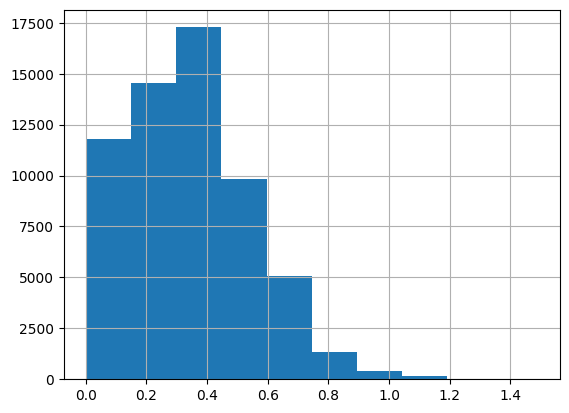

In [38]:
df['Whole weight.1'].hist(bins=10)

<Axes: >

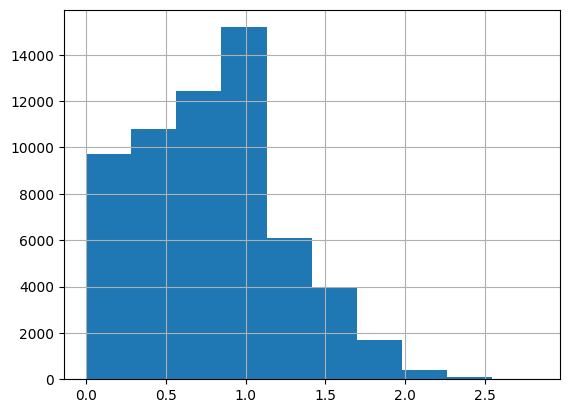

In [39]:
df['Whole weight'].hist(bins=10)

<Axes: >

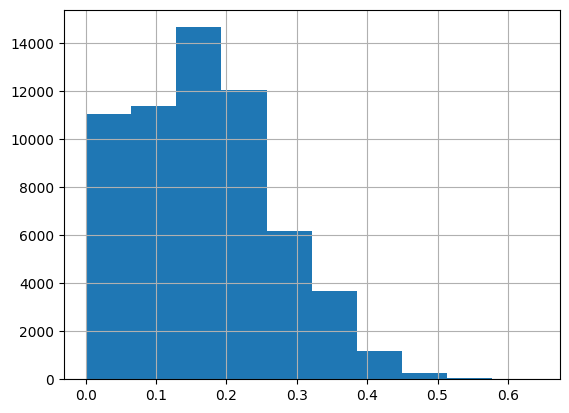

In [40]:
df['Whole weight.2'].hist(bins=10)

Since all the weights related features are right skewed. We do `np.log1p()` to make them more normal distributed.   

In [41]:
train_data.head()

,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings,volume,meat_ratio,shell_ratio,density
0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11,0.035475,0.425794,0.189890,21.747097
1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11,0.044762,0.405310,0.244690,25.244345
2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6,0.000440,0.261905,0.142857,47.619048
3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10,0.042394,0.410607,0.224713,21.571067
4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9,0.030664,0.472506,0.204604,25.501594


In [42]:
for df in [train_data, test_data]:
    for c in ['Whole weight','Whole weight.1','Whole weight.2','Shell weight']:
        df[c + '_log'] = np.log1p(df[c])

In [43]:
train_data.head()

,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings,volume,meat_ratio,shell_ratio,density,Whole weight_log,Whole weight.1_log,Whole weight.2_log,Shell weight_log
0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11,0.035475,0.425794,0.189890,21.747097,0.571827,0.284050,0.136714,0.215111
1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11,0.044762,0.405310,0.244690,25.244345,0.756122,0.377066,0.244122,0.277632
2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6,0.000440,0.261905,0.142857,47.619048,0.020783,0.005485,0.002996,0.004988
3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10,0.042394,0.410607,0.224713,21.571067,0.649456,0.318817,0.186894,0.223144
4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9,0.030664,0.472506,0.204604,25.501594,0.577736,0.314446,0.148420,0.180236


In [44]:
print(X[num_feats].replace([np.inf,-np.inf], np.nan).isna().sum())

Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
dtype: int64


In [45]:
from sklearn.preprocessing import PolynomialFeatures


new_feats = ["volume","meat_ratio","shell_ratio","density"] 

num_feats = ['Length','Diameter','Height','Whole weight',
         'Whole weight.1','Whole weight.2','Shell weight']

nun_feats = num_feats + new_feats

cat_feats = ['Sex']

num_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler()),
])


pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats),
    ('num', num_pipe, num_feats),
])


pipe = Pipeline([('pre',pre),('model',LinearRegression())])

X = train_data[num_feats+cat_feats] 
Y = np.log1p(train_data['Rings'])

cv = cross_val_score(pipe, X, Y, scoring='neg_root_mean_squared_error',cv=10) # 5 fold CV 
print(-cv.mean())

0.15519078818095028


In [46]:
 (( 0.16450563718421535 - 0.15519078818095028 ) /  0.16450563718421535 ) * 100

5.66232815039292

Thats a massive 5.6% improvement

In [47]:
pipe.fit(X,Y)
model = pipe.named_steps['model']  
model.coef_ , model.intercept_

(array([ 0.01655499, -0.03207389,  0.01551891,  0.13100383,  0.32320883,
         0.09809695, -0.10131827, -0.21493109,  0.07587853,  0.3480651 ,
         0.20377319, -0.6304689 , -0.11306848,  0.17710036,  0.09266612,
        -0.09574245, -0.27938245, -0.14978101,  0.08147862,  0.6261492 ,
        -0.39727277, -0.01700146,  0.27016529, -0.01284388,  0.10273593,
        -0.17841064, -0.0795315 ,  0.09934176, -0.05410358, -0.3521109 ,
        -0.07248016, -0.19797784,  0.41516034,  0.09257787,  0.06320437,
         0.11213727, -0.15112383, -0.00821897]),
 np.float64(2.3305282498793383))

In [48]:
for a in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([('pre',pre),("model",Ridge(alpha=a))])
    cv = cross_val_score(pipe,X,Y,scoring="neg_root_mean_squared_error",cv=5)
    print(f'alpha={a:6} {-cv.mean():.5f}')

alpha= 0.001 0.15523
alpha=  0.01 0.15523
alpha=   0.1 0.15522
alpha=   1.0 0.15521
alpha=  10.0 0.15526


alpha = 1 is the lowest. 

Ridge creates a U shaped graph from 0.15523 to 0.15522 to 0.15526 

Poly OLS and Ridge are almost identical. 

So which do you submit? When two models score identically, pick the one that's more robust, not the one that's 0.00002 lower. That's Ridge here. A tiny penalty costs you nothing measurable and protects against the model over-relying on any noisy polynomial term on unseen data — exactly what the hidden test set is. The leaderboard could even reward Ridge slightly for that. Picking the marginally-better-on-paper OLS would be chasing noise; picking Ridge is the disciplined call.

In [49]:
best = Pipeline([('pre', pre), ('model', Ridge(alpha=1.0))]).fit(X, Y)
sub_data['Rings'] = np.expm1(best.predict(test_data[num_feats + cat_feats]))
sub_data.to_csv('submission.csv', index=False)

In [50]:
sub_data.head()

,id,Rings
0,90615,9.301512
1,90616,9.791525
2,90617,10.260432
3,90618,10.041407
4,90619,7.670362
